# Grade-driven second-contract signal (2016+)
This ad-hoc workbook contrasts the scouting grade against the actual made_it_contract outcome that indicates a real second deal. After filtering the enriched contracts table to 2016+, we treat grade > 6 as the NFL-predicted second contract and compare it with the truth by school.

## Setup and data
1. load data/processed/draft_enriched_with_contracts.csv (records through 2025)
2. define 
fl_contract_pred as described above
3. keep only schools with at least 10 players so the school-level matrix is meaningful.

College logos live at C:\Users\sffra\Downloads\BSE 2025-2026\transfer-portal\adhoc\outputs\team_logos for optional visual context later.

In [58]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display, Markdown

sns.set(style='whitegrid', font_scale=1.1)
DATA_FILE = Path('data/processed/draft_enriched_with_contracts.csv')
LOGO_DIR = Path(r'C:\Users\sffra\Downloads\BSE 2025-2026\transfer-portal\adhoc\outputs\team_logos')


In [59]:
df = pd.read_csv("C:\\Users\\sffra\\Downloads\\BSE 2025-2026\\nfl-draft-nlp\\data\\processed\\draft_enriched_with_contracts.csv", usecols=['year', 'player_name', 'school', 'grade', 'made_it_contract'])
df = df[df['year'] <= 2021].copy()
df = df[df['year'] >= 2016].copy()
df['grade'] = pd.to_numeric(df['grade'], errors='coerce')
df['made_it_contract'] = pd.to_numeric(df['made_it_contract'], errors='coerce')
mask = df['grade'].notna() & df['made_it_contract'].notna()
df = df.loc[mask].astype({'made_it_contract': 'int64'})
df['nfl_contract_pred'] = (df['grade'] > 6.2).astype(int)
print(f"Shape after filtering: {df.shape[0]} rows (since 2016), {int(mask.sum())} valid grade/outcome pairs.")


Shape after filtering: 2641 rows (since 2016), 2641 valid grade/outcome pairs.


In [60]:
min_players = 20
school_counts = df['school'].value_counts()
eligible_schools = school_counts[school_counts >= min_players].index
df_school = df[df['school'].isin(eligible_schools)].copy()
print(f'Schools with >= {min_players} players: {len(eligible_schools)}')


Schools with >= 20 players: 47


In [61]:
matrix = pd.crosstab(
    df_school['school'],
    [df_school['nfl_contract_pred'], df_school['made_it_contract']],
    rownames=['School'],
    colnames=['Predicted', 'Actual']
).sort_index()
matrix.head()


Predicted       0       1    
Actual          0   1   0   1
School                       
ALABAMA        17  13  17  25
ARIZONA STATE  18   2   1   1
ARKANSAS       25   6   0   1
AUBURN         22  16   5   2
BAYLOR         15   2   3   1

In [62]:
summary = (
    df_school.groupby('school')
    .agg(total_players=('player_name', 'size'),
         actual_rate=('made_it_contract', 'mean'),
         predicted_rate=('nfl_contract_pred', 'mean'))
    .assign(actual_rate=lambda x: x['actual_rate'] * 100,
            predicted_rate=lambda x: x['predicted_rate'] * 100)
    .sort_values('total_players', ascending=False)
)
summary.head()


,total_players,actual_rate,predicted_rate
school,,,
ALABAMA,72,52.777778,58.333333
OHIO STATE,70,51.428571,34.285714
LSU,61,39.344262,34.426230
MICHIGAN,59,28.813559,18.644068
GEORGIA,58,24.137931,24.137931


### Predicted vs actual counts scatter (per school)
Scatter each school's predicted second-contract count (grade > 6) versus the actual made_it_contract count; bubble size reflects sample size and the dashed line marks perfect agreement.

C:\Users\sffra\AppData\Local\Temp\ipykernel_24440\3235262684.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


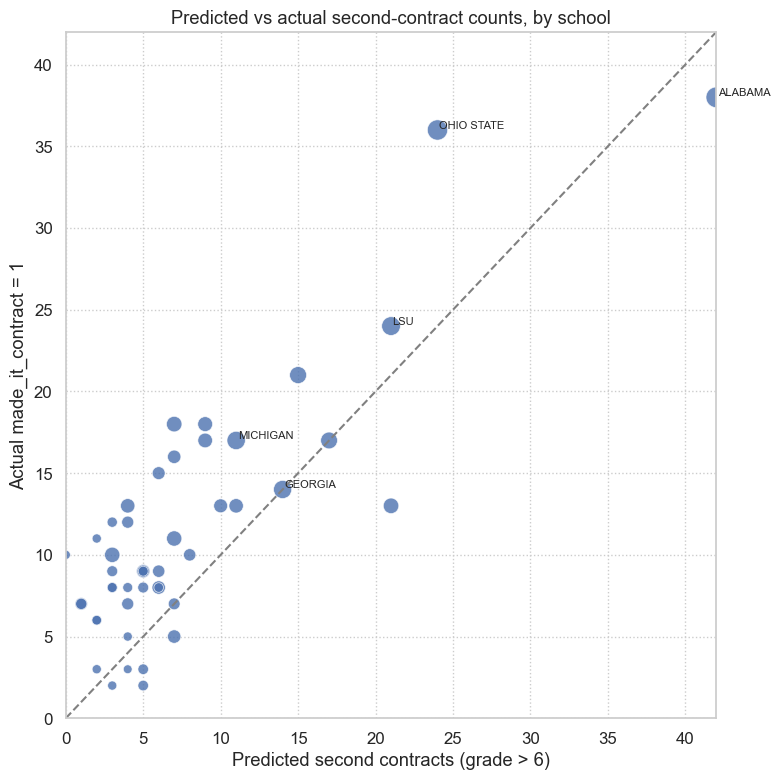

In [63]:
school_totals = (
    df_school.groupby('school')
    .agg(predicted_yes=('nfl_contract_pred', 'sum'),
         actual_yes=('made_it_contract', 'sum'),
         total_players=('player_name', 'size'))
    .sort_values('total_players', ascending=False)
)
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(
    data=school_totals,
    x='predicted_yes',
    y='actual_yes',
    size='total_players',
    sizes=(40, 220),
    palette='tab10',
    alpha=0.8,
    legend=False,
    ax=ax
)
max_val = max(school_totals[['predicted_yes', 'actual_yes']].values.max(), 1)
ax.plot([0, max_val], [0, max_val], linestyle='--', color='gray', label='Perfect agreement')
for school in school_totals.head(5).index:
    ax.text(
        school_totals.loc[school, 'predicted_yes'] + 0.1,
        school_totals.loc[school, 'actual_yes'] + 0.1,
        school,
        fontsize=8
    )
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_title('Predicted vs actual second-contract counts, by school')
ax.set_xlabel('Predicted second contracts (grade > 6)')
ax.set_ylabel('Actual made_it_contract = 1')
ax.grid(True, linestyle=':')
plt.tight_layout()


### Schools with the largest prediction mismatches (min 50 players)
We take the subset of schools with at least 50 players since 2016 and highlight the biggest positive or negative gaps between actual second contracts and those the NFL-grade rule predicted.

In [ ]:
min_delta_players = 10
large_schools = school_counts[school_counts >= min_delta_players].index
delta_scope = school_totals.loc[school_totals.index.isin(large_schools)].copy()
delta_scope['delta'] = delta_scope['actual_yes'] - delta_scope['predicted_yes']
delta_scope['abs_delta'] = delta_scope['delta'].abs()
delta_scope = delta_scope.sort_values('abs_delta', ascending=False)
delta_scope[['predicted_yes', 'actual_yes', 'delta', 'total_players']].head(22)


,predicted_yes,actual_yes,delta,total_players
school,,,,
OHIO STATE,24,36,12,70
AUBURN,7,18,11,45
NEBRASKA,0,10,10,22
WISCONSIN,4,13,9,40
N.C. STATE,3,12,9,25
IOWA,7,16,9,36
OKLAHOMA,9,18,9,42
STANFORD,6,15,9,34
BOSTON COLLEGE,2,11,9,22


: 

### Schools outperforming the grade-based prediction (min 50 players)
List schools where actual second-contract counts exceed the prediction and show how much more they deliver.

In [65]:
overperformers = delta_scope[delta_scope['delta'] > 0].sort_values('delta', ascending=False)
overperformers[['actual_yes', 'predicted_yes', 'delta', 'total_players']].head(10)


,actual_yes,predicted_yes,delta,total_players
school,,,,
OHIO STATE,36,24,12,70
NOTRE DAME,21,15,6,52
MICHIGAN,17,11,6,59
LSU,24,21,3,61


### Confusion matrix heatmap (top schools)
Plot the predicted vs actual counts for the schools with the largest samples, normalized to highlight the confusion structure.

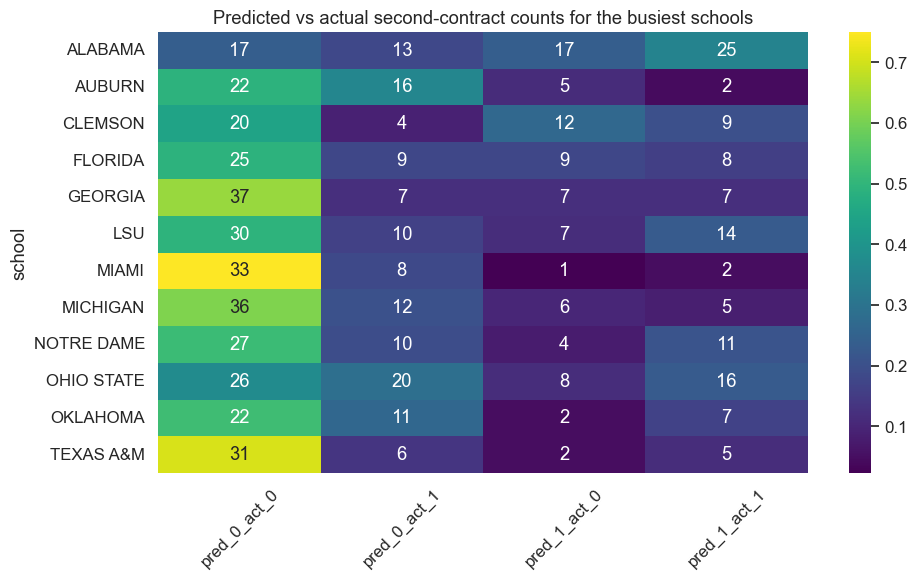

In [66]:
top_schools = summary.head(12).index
heat = (
    df_school.loc[df_school['school'].isin(top_schools)]
    .groupby(['school', 'nfl_contract_pred', 'made_it_contract'])
    .size()
    .unstack(level=[1, 2], fill_value=0)
)
heat.columns = [f'pred_{pred}_act_{act}' for pred, act in heat.columns]
heat_norm = heat.div(heat.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heat_norm, annot=heat, fmt='d', cmap='viridis', ax=ax)
ax.set_title('Predicted vs actual second-contract counts for the busiest schools')
plt.xticks(rotation=45)
plt.tight_layout()


### Logos for the busiest schools (optional)
We can plug logos from the shared directory to keep the notebook consistent with other visual deliverables.

**ALABAMA**

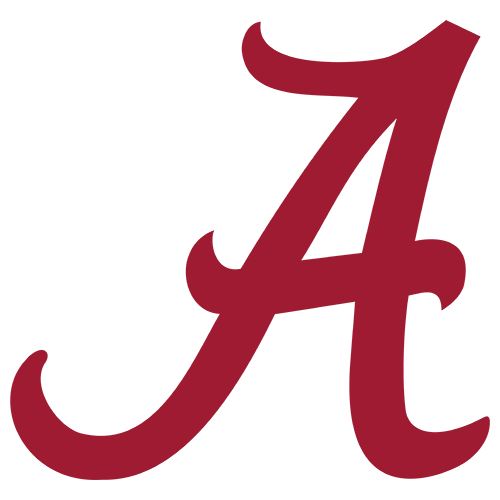

**OHIO STATE**

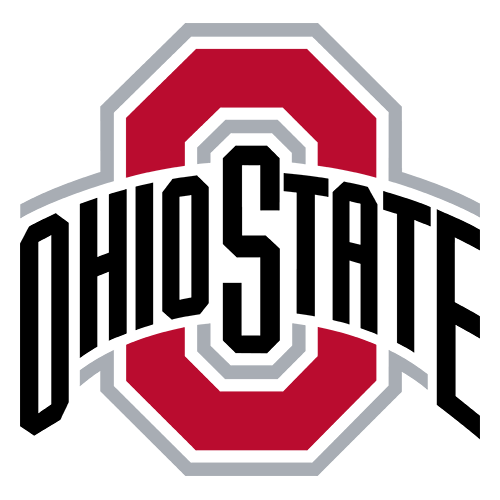

**LSU**

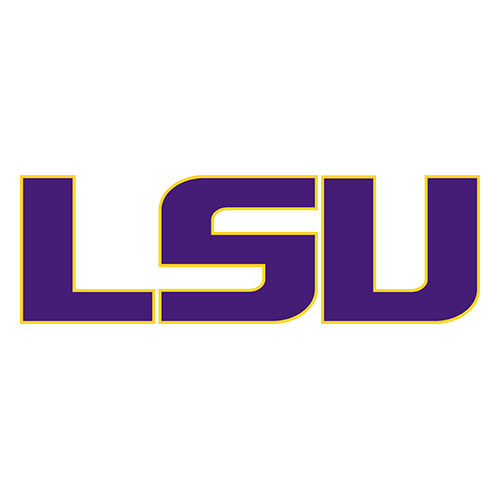

In [67]:
logo_lookup = {path.stem: path for path in LOGO_DIR.glob('*.png')}
def normalized_school_key(school: str) -> str:
    cleaned = school.lower().replace('&', 'and').replace(' ', '_').replace('-', '_').replace('.', '').replace("'", '')
    cleaned = cleaned.replace('stateuniversity', 'state').replace('universityof', '')
    return cleaned

for school in summary.head(3).index:
    key = normalized_school_key(school)
    logo_path = logo_lookup.get(key)
    display(Markdown(f'**{school}**'))
    if logo_path and logo_path.exists():
        display(Image(str(logo_path)))
    else:
        display(Markdown(f'_logo missing for {school} (tried {key}.png)_'))
